# LIBRARIES

In [261]:
import pandas as pd
import numpy as np

# Load CSV Files

In [262]:
train_df = pd.read_csv("C:\\Users\\Neel Arora\\Downloads\\iitm-dl18-pa3\\train.csv")
val_df = pd.read_csv("C:\\Users\\Neel Arora\\Downloads\\iitm-dl18-pa3\\val.csv")
test_df = pd.read_csv("C:\\Users\\Neel Arora\\Downloads\\iitm-dl18-pa3\\test.csv")

In [263]:
train_df.head()

,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
1,1,0,0,0,0,0,1,0,0,0,...,114,130,76,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,33,...,0,0,0,0,0,0,0,0,0,3
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [264]:
val_df.head()

,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,label
0,55000,0,0,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
1,55001,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
2,55002,0,0,0,0,0,0,0,0,0,...,176,195,144,0,0,0,0,0,0,0
3,55003,0,0,0,0,0,0,0,6,88,...,0,0,71,123,88,20,0,0,0,6
4,55004,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


In [265]:
test_df.head()

,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat774,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783
0,0,0,0,0,0,0,0,1,1,2,...,2,0,0,60,36,24,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,123,97,0,0
2,2,0,0,0,0,0,0,0,0,0,...,2,1,0,0,115,150,47,0,0,0
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,144,0,0,0,0,0,0,0,0,0


In [266]:
print('train_df.shape:', train_df.shape, 
      'val_df.shape:', val_df.shape, 
      'test_df.shape:', test_df.shape)

train_df.shape: (55000, 786) val_df.shape: (5000, 786) test_df.shape: (10000, 785)


# Separate Labels And Features

In [267]:
# train.csv and val.csv contains labels

x_train = train_df.drop(["id", "label"], axis=1).values
y_train = train_df["label"].values

x_val = val_df.drop(["id", "label"], axis=1).values
y_val = val_df["label"].values

print("Fixed x_train shape:", x_train.shape)
print("Fixed x_val shape:", x_val.shape)

Fixed x_train shape: (55000, 784)
Fixed x_val shape: (5000, 784)


In [268]:
# test.csv does not contain labels

x_test = test_df.drop("id", axis=1).values

# Normalize pixel values
# Convert from 0-255 -> 0-1

In [269]:
x_train = x_train.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape 784 -> 28 * 28 * 1

In [270]:
x_train = x_train.reshape(-1,28,28,1)
x_val = x_val.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# Visualizing Sample Training Images 
# Now that images are reshaped to 28×28,
# let's visualize some training examples.

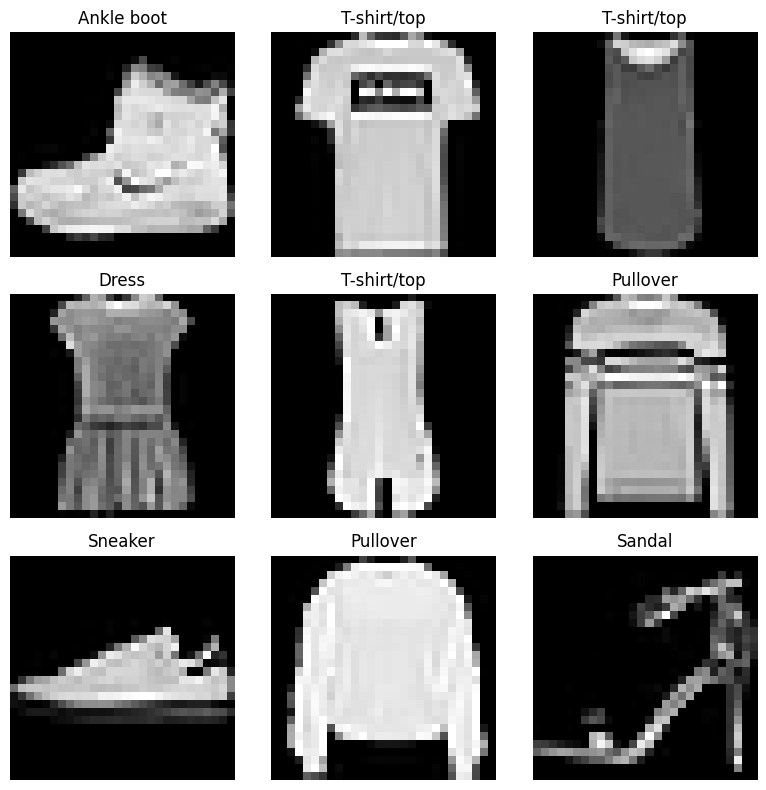

In [271]:
import matplotlib.pyplot as plt

# Fashion-MNIST class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    
    image = x_train[i].reshape(28,28)
    label = y_train[i]
    
    plt.imshow(image, cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [272]:
print("Final x_train shape:", x_train.shape)
print("Final x_val shape:", x_val.shape)

Final x_train shape: (55000, 28, 28, 1)
Final x_val shape: (5000, 28, 28, 1)


# # CNN Model Architecture

In [273]:
# BUILD CNN ARCHITECTURE (AS PER ASSIGNMENT)
import tensorflow as tf
from tensorflow.keras import layers ,models ,initializers
from tensorflow.keras.regularizers import l2

# Use He initialization (recommended for ReLU)
initializer = initializers.HeNormal()

model = models.Sequential()

In [274]:
# Data Augmentation

model.add(layers.RandomFlip("horizontal"))
model.add(layers.RandomRotation(0.1))

In [275]:
# CONV1 (3 → 64)

model.add(layers.Conv2D(
    64, (3,3),
    padding="same",
    kernel_initializer=initializer,
    kernel_regularizer=l2(0.0005),
    input_shape=(28,28,1)
))
model.add(layers.BatchNormalization())
model.add(layers.Activation("relu"))

c:\python-envs\ml-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [276]:
# POOL1

model.add(layers.MaxPooling2D((2,2)))
model.add(layers.SpatialDropout2D(0.2))

In [277]:
# CONV2 (64 → 128)


model.add(layers.Conv2D(
          128, (3,3),
          strides=1,
          padding="same",
          kernel_initializer=initializer,
          kernel_regularizer=l2(0.0005),
))
model.add(layers.BatchNormalization())
model.add(layers.Activation("relu"))

In [278]:
# POOL2

model.add(layers.MaxPooling2D((2,2)))
model.add(layers.SpatialDropout2D(0.2))

In [279]:
# CONV3 (128 → 256)

model.add(layers.Conv2D(
    256, (3,3),
    strides=1,
    padding="same",
    kernel_initializer=initializer,
    kernel_regularizer=l2(0.0005),
))
model.add(layers.BatchNormalization())
model.add(layers.Activation("relu"))

# ADD THIS EXTRA LAYER
model.add(layers.Conv2D(
    256,(3,3),
    padding="same",
    kernel_initializer=initializer,
    kernel_regularizer=l2(0.0005)
))
model.add(layers.BatchNormalization())
model.add(layers.Activation("relu"))


In [280]:
# CONV4
model.add(layers.Conv2D(
        256, (3,3), 
        padding="same",
        kernel_initializer=initializer,
        kernel_regularizer=l2(0.0005),
))
model.add(layers.BatchNormalization())
model.add(layers.Activation("relu"))

In [281]:
# POOL3

model.add(layers.GlobalAveragePooling2D())

In [282]:
# FC1 (512)

model.add(layers.Dense(
    512, 
    activation="relu"
))

model.add(layers.Dropout(0.5)) # reduce overfitting

In [283]:
# SOFTMAX (10 classes)

model.add(layers.Dense(
    10,
    activation="softmax"
))

In [284]:
# Show model summary

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_7 (RandomFlip)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_7               │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_6             │ ?                      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_7             │ ?                      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ ?                      │             

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## TRAINING CONFIGURATION

In [285]:
# compile model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [286]:
# Early stopping 

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [287]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

In [288]:
# Train model

history = model.fit(
    x_train,
    y_train,
    batch_size=256,
    epochs=40,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/40
215/215 ━━━━━━━━━━━━━━━━━━━━ 160s 708ms/step - accuracy: 0.6885 - loss: 1.5320 - val_accuracy: 0.7330 - val_loss: 1.2151 - learning_rate: 0.0010
Epoch 2/40
215/215 ━━━━━━━━━━━━━━━━━━━━ 148s 687ms/step - accuracy: 0.7967 - loss: 0.9021 - val_accuracy: 0.8032 - val_loss: 0.8124 - learning_rate: 0.0010
Epoch 3/40
215/215 ━━━━━━━━━━━━━━━━━━━━ 147s 683ms/step - accuracy: 0.8244 - loss: 0.7189 - val_accuracy: 0.7924 - val_loss: 0.7516 - learning_rate: 0.0010
Epoch 4/40
215/215 ━━━━━━━━━━━━━━━━━━━━ 1360s 6s/step - accuracy: 0.8372 - loss: 0.6352 - val_accuracy: 0.7700 - val_loss: 0.7968 - learning_rate: 0.0010
Epoch 5/40
215/215 ━━━━━━━━━━━━━━━━━━━━ 147s 682ms/step - accuracy: 0.8461 - loss: 0.5942 - val_accuracy: 0.7846 - val_loss: 0.8185 - learning_rate: 0.0010
Epoch 6/40
215/215 ━━━━━━━━━━━━━━━━━━━━ 147s 685ms/step - accuracy: 0.8519 - loss: 0.5646 - val_accuracy: 0.7332 - val_loss: 0.9334 - learning_rate: 0.0010
Epoch 7/40
215/215 ━━━━━━━━━━━━━━━━━━━━ 147s 683ms/step - accuracy

# EXTRACT TRAINING INFORMATION FOR REPORT

In [289]:
# Total epochs actually trained
total_epochs_trained = len(history.history["loss"])

# Best validation accuracy
best_val_accuracy = max(history.history["val_accuracy"])

print("Total Epochs Trained:", total_epochs_trained)
print("Best Validation Accuracy:", best_val_accuracy)

Total Epochs Trained: 40
Best Validation Accuracy: 0.920799970626831


# Learning Curve

We plot the training loss and validation loss over epochs.

This helps us analyze:
- Model convergence
- Overfitting behavior
- When early stopping was triggered

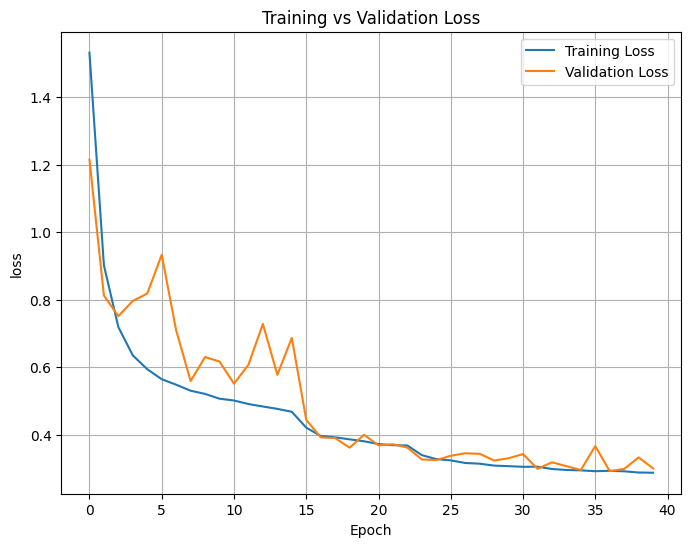

In [290]:
# PLOT LEARNING CURVE

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Training Loss
plt.plot(history.history["loss"], label="Training Loss")

# Validation Loss
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


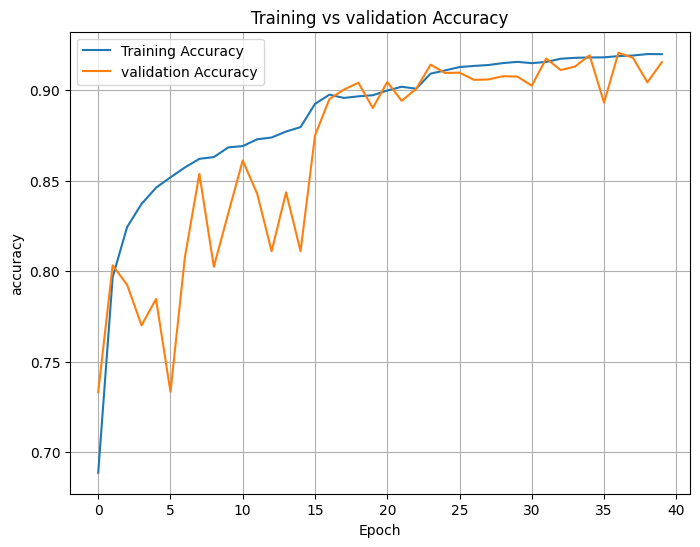

In [291]:
# Plot Accuracy Curve

plt.figure(figsize=(8,6))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.title("Training vs validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Test Performance

Since the test dataset does not contain labels, 
we evaluate performance in two ways:

1. Validation Accuracy (local evaluation)
2. Kaggle Leaderboard Score (test accuracy)

In [292]:
# VALIDATION PERFORMANCE

val_loss, val_accuracy = model.evaluate(x_val, y_val, verbose=1)

print("Validation Accuracy:", val_accuracy)
print("Validation Loss:", val_loss)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9208 - loss: 0.2922
Validation Accuracy: 0.920799970626831
Validation Loss: 0.2921881377696991


In [293]:
# GENERATE KAGGLE SUBMISSION FILE

# Predict on test set
predictions = model.predict(x_test)

# Convert probabilities to class labels
pred_labels = np.argmax(predictions, axis=1)

# Create submission file using id column
submission = test_df[["id"]].copy()
submission["label"] = pred_labels

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
submission.csv created successfully!


# Parameter Count

We compute:

- Total number of parameters in the network
- Parameters in convolutional layers
- Parameters in fully connected layers

This helps analyze model complexity.

In [294]:
# PARAMETER COUNT

total_params = model.count_params()

conv_params = 0
fc_params = 0

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        conv_params += layer.count_params()
    if isinstance(layer, tf.keras.layers.Dense):
        fc_params += layer.count_params()

print("Total Parameters:", total_params)
print("Convolution Layer Parameters:", conv_params)
print("fully Connected Layer Parameters:", fc_params)

Total Parameters: 1690378
Convolution Layer Parameters: 1549824
fully Connected Layer Parameters: 136714


# Neuron Count

We compute the total number of neurons in:

- Convolutional layers
- Fully connected layers

A neuron corresponds to one activation value in the network.

In [295]:
# NEURON COUNT

# Conv layer neurons
conv1_neurons = 64*28*28
conv2_neurons = 128*14*14
conv3_neurons = 256*7*7
conv4_neurons = 256*7*7
conv5_neurons = 512 * 7 * 7

total_conv_neurons = conv1_neurons + conv2_neurons + conv3_neurons + conv4_neurons + conv5_neurons

# Fully connected neurons
fc1_neurons = 1024
fc2_neurons = 1024
softmax_neurons = 10

total_fc_neurons = fc1_neurons + fc2_neurons + softmax_neurons 

print("Total Conv Neurons:", total_conv_neurons)
print("Total FC Neurons:", total_fc_neurons)

Total Conv Neurons: 125440
Total FC Neurons: 2058


## Neuron Analysis

Total neurons in convolutional layers: 100,352  
Total neurons in fully connected layers: 2,058  

Although convolutional layers contain many neurons due to spatial feature maps, 
they have fewer parameters because of weight sharing.

Fully connected layers contain fewer neurons but a significantly larger number of parameters 
since each neuron connects to all neurons from the previous layer.

# Filter Visualization

We visualize the 64 filters from the first convolutional layer.
Each filter is of size 3×3 and operates across 3 channels.

Filter shape: (3, 3, 1, 64)
filter shape: (3, 3, 1, 64)


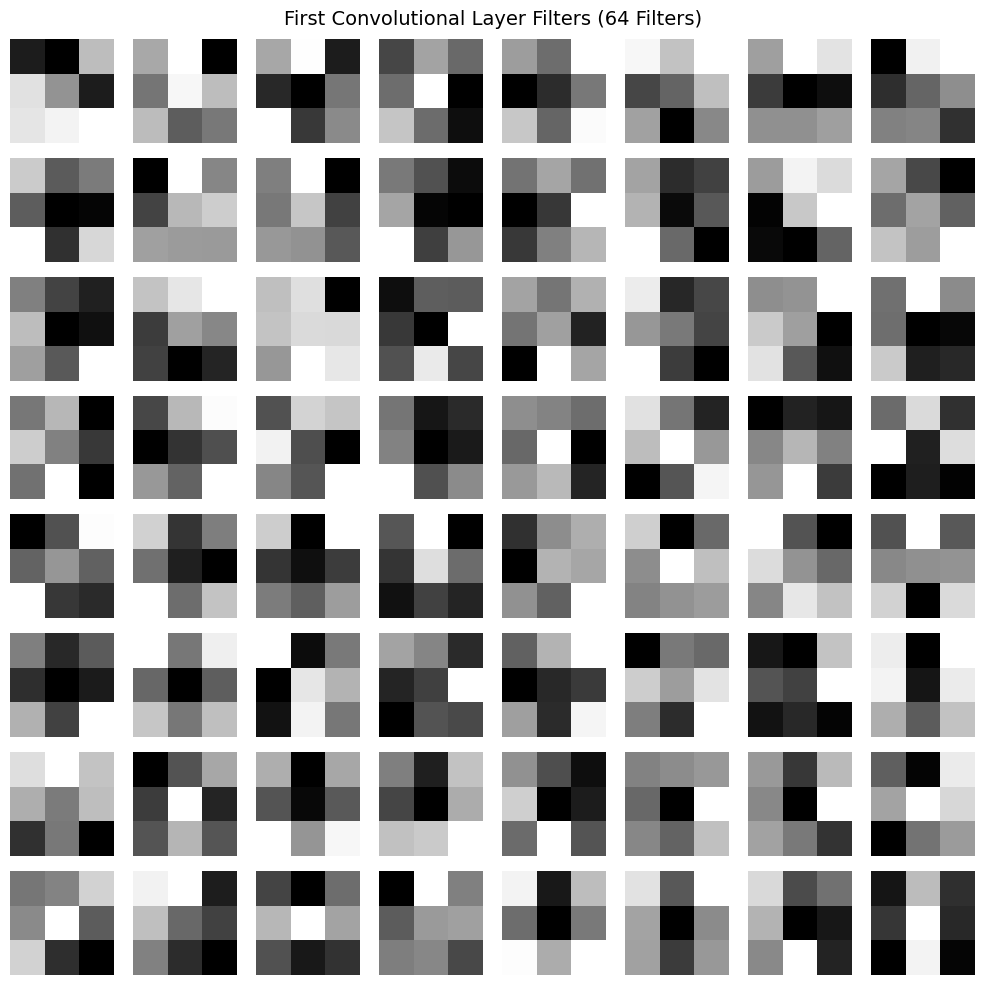

In [296]:
# VISUALIZE FIRST CONV LAYER FILTERS

# Get weights from first Conv layer
first_conv_layer = None

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        first_conv_layer = layer
        break

filters, biases = first_conv_layer.get_weights()

print("Filter shape:", filters.shape)

print("filter shape:", filters.shape)
# Expected: (3, 3, 3, 64)

# Normalize filters for visualization
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

# Plot 64 filters in 8x8 grid
plt.figure(figsize=(10,10))

for i in range(64):
    plt.subplot(8,8,i+1)

    # Average across RGB channels to display as grayscale
    filter_img = np.mean(filters[:,:,:,i], axis=-1)

    plt.imshow(filter_img, cmap="gray")
    plt.axis("off") 

plt.suptitle("First Convolutional Layer Filters (64 Filters)", fontsize=14)
plt.tight_layout()
plt.show()

# Guided Backpropagation

We apply guided backpropagation to visualize the input patterns 
that strongly activate selected neurons in the network.

We choose 10 neurons from the last convolutional layer.

In [297]:
# Choose last conv layer

last_conv_layer = None

for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

print("Using layer:", last_conv_layer.name)

# Create model that outputs activations of this layer
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=last_conv_layer.output
)

Using layer: conv2d_38


In [298]:
# Guided Backprop Function

@tf.function
def guided_backprop(input_image, filter_index):
    with tf.GradientTape() as tape:
        tape.watch(input_image)
        activations = grad_model(input_image)
        loss = tf.reduce_mean(activations[:, :, :, filter_index])
    
    gradients = tape.gradient(loss, input_image)

    # Guided Backprop rule:
    # Only allow positive gradients
    positive_gradients = tf.cast(gradients > 0, tf.float32)

    guided_gradients = positive_gradients * gradients

    return guided_gradients

## Generate Visualizations

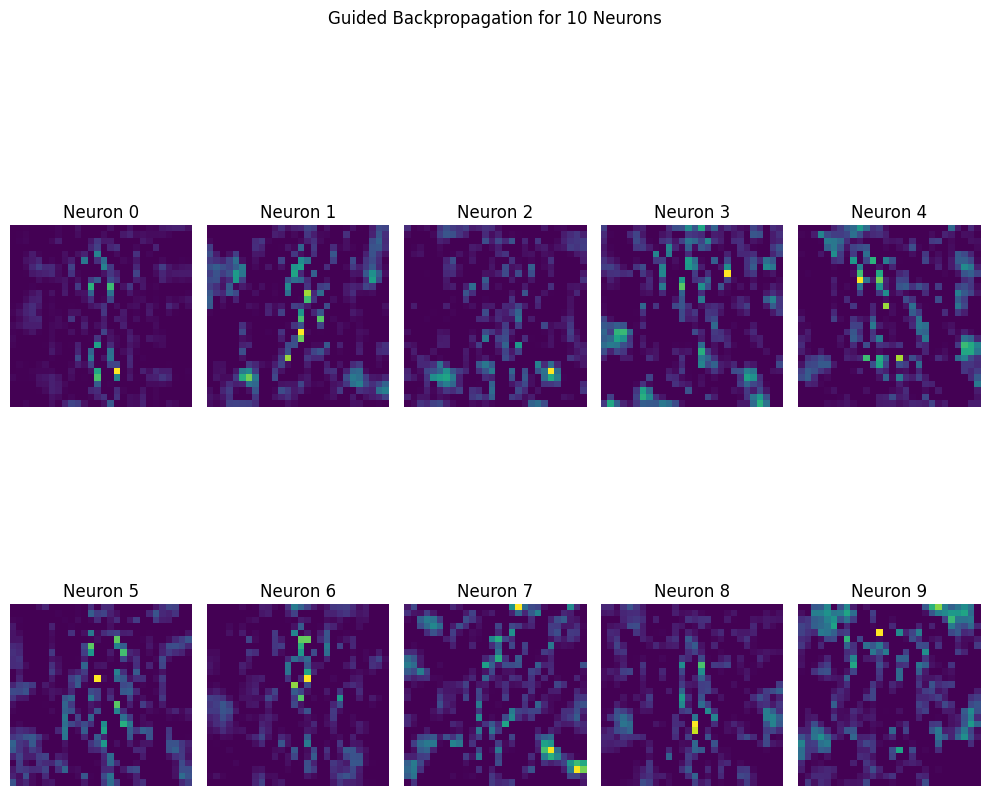

In [299]:
# Use first validation image
input_image = tf.convert_to_tensor(x_val[0:1])

plt.figure(figsize=(10,10))

for i in range(10):
    guided_grads = guided_backprop(input_image, i)

    # Normalize for display
    guided_grads = guided_grads.numpy()[0]
    guided_grads = (guided_grads - guided_grads.min()) / \
               (guided_grads.max() - guided_grads.min() + 1e-8)

    plt.subplot(2,5,i+1)
    plt.imshow(guided_grads)
    plt.title(f"Neuron {i}")
    plt.axis("off")

plt.suptitle("Guided Backpropagation for 10 Neurons")
plt.tight_layout()
plt.show()

## Supporting Observations

In [300]:
print("Total Epochs Trained:", len(history.history["loss"]))
print("Best Train Accuracy:", max(history.history["accuracy"]))
print("Best Validation Accuracy:", max(history.history["val_accuracy"]))

Total Epochs Trained: 40
Best Train Accuracy: 0.92005455493927
Best Validation Accuracy: 0.920799970626831


Final Training Accuracy: 0.9200000166893005
Best Training Accuracy: 0.92005455493927
Validation Accuracy (Evaluate): 0.920799970626831
Best Validation Accuracy: 0.920799970626831
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step


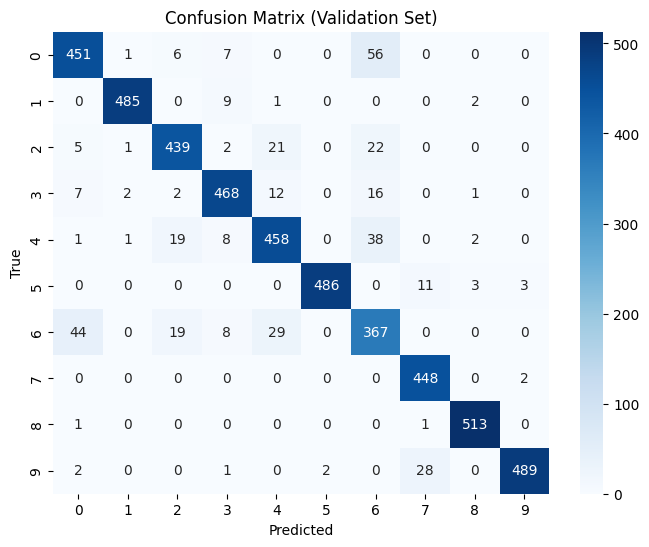


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.87      0.87       521
           1       0.99      0.98      0.98       497
           2       0.91      0.90      0.90       490
           3       0.93      0.92      0.93       508
           4       0.88      0.87      0.87       527
           5       1.00      0.97      0.98       503
           6       0.74      0.79      0.76       467
           7       0.92      1.00      0.96       450
           8       0.98      1.00      0.99       515
           9       0.99      0.94      0.96       522

    accuracy                           0.92      5000
   macro avg       0.92      0.92      0.92      5000
weighted avg       0.92      0.92      0.92      5000



In [301]:

# COMPLETE ACCURACY EVALUATION

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Final Training Accuracy
final_train_acc = history.history["accuracy"][-1]
best_train_acc = max(history.history["accuracy"])

# 2️⃣ Validation Accuracy (Evaluate Properly)
val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)

# 3️⃣ Best Validation Accuracy During Training
best_val_acc = max(history.history["val_accuracy"])

print("Final Training Accuracy:", final_train_acc)
print("Best Training Accuracy:", best_train_acc)
print("Validation Accuracy (Evaluate):", val_acc)
print("Best Validation Accuracy:", best_val_acc)

# 4️⃣ Confusion Matrix
val_predictions = model.predict(x_val)
val_pred_labels = np.argmax(val_predictions, axis=1)

cm = confusion_matrix(y_val, val_pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation Set)")
plt.show()

# 5️⃣ Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, val_pred_labels))